In [1]:
from IPython.display import display, HTML

display(HTML("<style>.container { width:100% !important; }</style>"))

In [2]:
import sys

# This must print the path to your GENAI venv, not system Python
print("Python path:", sys.executable)

# Confirm all required packages are available
import pandas as pd
import sklearn
import matplotlib
import nltk
print("All packages loaded ✅")
print(f"pandas version  : {pd.__version__}")
print(f"sklearn version : {sklearn.__version__}")

Python path: c:\Users\KaoticCharma\Documents\Ironhack\GENAI\Scripts\python.exe
All packages loaded ✅
pandas version  : 3.0.1
sklearn version : 1.8.0


# Lab | Natural Language Processing
### SMS: SPAM or HAM

### Let's prepare the environment

In [7]:
#!pip install seaborn
import seaborn as sns

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split , StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

- Read Data for the Fraudulent Email Kaggle Challenge
- Reduce the training set to speead up development. 

In [ ]:
## Read Data for the Fraudulent Email Kaggle Challenge
data = pd.read_csv("kg_train.csv",encoding='latin-1')
data_test = pd.read_csv("kg_test.csv",encoding='latin-1')
# Reduce the training set to speed up development. 
# Modify for final system
data = data.head(1000)
print(data.shape)




### Let's divide the training and test set into two partitions

In [5]:
# Your code
# Here the kg_train.csv data is used solely as training / test data
# And kg_test.csv is used solely for predictions
seed = 42
df_train = pd.read_csv("kg_train.csv")

df_train.info()
df_train['text']
df_train['label'] 

# Split Df_train
X =df_train['text']
y = df_train['label']

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=seed,
    stratify=y
    )
# To check class ratios are preserved : 
print(f"Train distribution : {y_train.value_counts(normalize=True)}")
print(f"Validation distribution : {y_val.value_counts(normalize=True)}")

<class 'pandas.DataFrame'>
RangeIndex: 5964 entries, 0 to 5963
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    5964 non-null   str  
 1   label   5964 non-null   int64
dtypes: int64(1), str(1)
memory usage: 93.3 KB
Train distribution : label
0    0.567628
1    0.432372
Name: proportion, dtype: float64
Validation distribution : label
0    0.568075
1    0.431925
Name: proportion, dtype: float64


In [6]:
# Using Stratified K-fold cross validation.

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
for fold, (train_idx,val_idx) in enumerate(skf.split(X,y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    vec = TfidfVectorizer()
    X_train_vec = vec.fit_transform(X_train)
    X_val_vec = vec.transform(X_val)

    clf = LogisticRegression()
    clf.fit(X_train_vec,y_train)

    print(f"Train distribution : {y.iloc[train_idx].value_counts(normalize=True)}")
    print(f"Validation distribution : {y.iloc[val_idx].value_counts(normalize=True)}")  
    
    predicts = clf.predict(X_val_vec)
    print(f"\n Fold {fold + 1} : \n",classification_report(y_val,predicts))

X_test_final = vec.transform(data_test['text'].values)
final_predicts = clf.predict(X_test_final)
  


Train distribution : label
0    0.567805
1    0.432195
Name: proportion, dtype: float64
Validation distribution : label
0    0.567477
1    0.432523
Name: proportion, dtype: float64

 Fold 1 : 
               precision    recall  f1-score   support

           0       0.95      1.00      0.97       677
           1       1.00      0.93      0.96       516

    accuracy                           0.97      1193
   macro avg       0.97      0.96      0.97      1193
weighted avg       0.97      0.97      0.97      1193

Train distribution : label
0    0.567805
1    0.432195
Name: proportion, dtype: float64
Validation distribution : label
0    0.567477
1    0.432523
Name: proportion, dtype: float64

 Fold 2 : 
               precision    recall  f1-score   support

           0       0.97      1.00      0.98       677
           1       1.00      0.95      0.97       516

    accuracy                           0.98      1193
   macro avg       0.98      0.98      0.98      1193
weighted avg 

NameError: name 'data_test' is not defined

In [8]:
import pandas as pd

# Load training data with latin-1 encoding to handle special/non-UTF8 characters
# Email datasets often contain raw byte sequences that break default UTF-8 decoding
df_train = pd.read_csv("kg_train.csv", encoding='latin-1')

# Load test data — this has NO label column, used only for final Kaggle predictions
df_test = pd.read_csv("kg_test.csv", encoding='latin-1')

# Slice first 1000 rows to speed up development (remove .head() for full training)
# .copy() prevents SettingWithCopyWarning when mutating this DataFrame later
data = df_train.head(1000).copy()

# ── Sanity Checks ──────────────────────────────────────────────────────────────

# Confirm shapes: how many rows and columns each dataset has
print("TRAIN (full)   :", df_train.shape)
print("TRAIN (reduced):", data.shape)
print("TEST           :", df_test.shape)

# Check column names and data types — expect: text=object, label=int64
print("\nTraining dtypes:\n", df_train.dtypes)
print("\nTest dtypes:\n", df_test.dtypes)

# Check class distribution — label 1 = SPAM, label 0 = HAM
print("\nClass distribution:")
print(data['label'].value_counts())

# Check class proportions as percentages
print("\nClass proportion (%):")
print(data['label'].value_counts(normalize=True).mul(100).round(2))

# Check for null values — NaN in text column will crash TfidfVectorizer downstream
print("\nNull values:")
print(data.isnull().sum())


TRAIN (full)   : (5964, 2)
TRAIN (reduced): (1000, 2)
TEST           : (5964, 1)

Training dtypes:
 text       str
label    int64
dtype: object

Test dtypes:
 text    str
dtype: object

Class distribution:
label
0    558
1    442
Name: count, dtype: int64

Class proportion (%):
label
0    55.8
1    44.2
Name: proportion, dtype: float64

Null values:
text     0
label    0
dtype: int64


In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split

# ── Load the FULL training data (not the reduced 1000-row version) ─────────────
# We use the full dataset here for a proper train/val split
df_train = pd.read_csv("kg_train.csv", encoding='latin-1')

# Separate features (X) and target labels (y)
# X → the raw email text column
# y → the label column (0 = HAM, 1 = SPAM)
X = df_train['text']
y = df_train['label']

# ── Stratified Split ───────────────────────────────────────────────────────────
# test_size=0.25 → 75% train, 25% validation
# random_state=42 → fixes the random seed so results are reproducible every run
# stratify=y → CRITICAL: ensures both splits maintain the same SPAM/HAM ratio
#              Without this, a random split could put most SPAM in one partition
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# ── Verification ───────────────────────────────────────────────────────────────
# Print shapes to confirm correct split sizes
print(f"X_train shape : {X_train.shape}")   # ~75% of 5964 rows
print(f"X_val shape   : {X_val.shape}")     # ~25% of 5964 rows
print(f"y_train shape : {y_train.shape}")
print(f"y_val shape   : {y_val.shape}")

# Confirm that class ratios are preserved in BOTH splits
# Both should show ~56.7% HAM and ~43.2% SPAM — matching the original distribution
print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nValidation class distribution:")
print(y_val.value_counts(normalize=True).mul(100).round(2))


X_train shape : (4473,)
X_val shape   : (1491,)
y_train shape : (4473,)
y_val shape   : (1491,)

Train class distribution:
label
0    56.76
1    43.24
Name: proportion, dtype: float64

Validation class distribution:
label
0    56.81
1    43.19
Name: proportion, dtype: float64


## Data Preprocessing

In [10]:
import string
from nltk.corpus import stopwords
print(string.punctuation)
print(stopwords.words("english")[100:110])
from nltk.stem.snowball import SnowballStemmer
snowball = SnowballStemmer('english')

!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~
['needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on']


## Now, we have to clean the html code removing words

- First we remove inline JavaScript/CSS
- Then we remove html comments. This has to be done before removing regular tags since comments can contain '>' characters
- Next we can remove the remaining tags

#### Research : how to identify inline Javascript , HTML and CSS ?

In [11]:
# Your code

# First we start with special Characters 
import re
import pandas as pd

# ── RESEARCH: How to identify inline JS, CSS and HTML ─────────────────────────
# Inline JS  → lives inside <script>...</script> tags
# Inline CSS → lives inside <style>...</style> tags
# HTML comments → <!-- this format --> must be removed BEFORE stripping tags
#                 because comments can contain '>' which confuses the tag stripper
# HTML tags  → anything remaining in the form <tag> or </tag> or <tag />

# ── Step 1: Remove inline JavaScript ──────────────────────────────────────────
# re.DOTALL makes '.' match newlines too — JS blocks often span multiple lines
# re.IGNORECASE handles <SCRIPT>, <Script>, <script> etc.
def remove_inline_js(text):
    # Matches everything between <script ...> and </script> inclusive
    return re.sub(r'<script[^>]*>.*?</script>', '', text, flags=re.DOTALL | re.IGNORECASE)

# ── Step 2: Remove inline CSS ─────────────────────────────────────────────────
# Same logic as JS but targets <style>...</style> blocks
def remove_inline_css(text):
    return re.sub(r'<style[^>]*>.*?</style>', '', text, flags=re.DOTALL | re.IGNORECASE)

# ── Step 3: Remove HTML comments ──────────────────────────────────────────────
# HTML comments: <!-- any content here -->
# MUST be done before removing tags because comments can contain '>'
# which would confuse the generic tag stripper into stopping too early
def remove_html_comments(text):
    return re.sub(r'<!--.*?-->', '', text, flags=re.DOTALL)

# ── Step 4: Remove remaining HTML tags ────────────────────────────────────────
# Matches any leftover tag: <br>, </p>, <a href="...">, etc.
# [^>]* matches any characters except '>' inside the tag (attributes, etc.)
def remove_html_tags(text):
    return re.sub(r'<[^>]+>', '', text)

# ── Step 5: Decode common HTML entities ───────────────────────────────────────
# Emails often contain encoded characters like =3D (=), =2E (.), =20 (space)
# These are Quoted-Printable encodings used in email transmission
# We use a library approach — more reliable than manual regex
import html
def decode_html_entities(text):
    # Converts &amp; → &, &lt; → <, &#39; → ', etc.
    return html.unescape(text)

# ── Master HTML Cleaner — applies all steps in the correct order ──────────────
def clean_html(text):
    # Guard against NaN values that would crash string operations
    if not isinstance(text, str):
        return ""
    text = remove_inline_js(text)       # 1. Strip JS first
    text = remove_inline_css(text)      # 2. Strip CSS second
    text = remove_html_comments(text)   # 3. Strip comments before tags
    text = remove_html_tags(text)       # 4. Strip remaining HTML tags
    text = decode_html_entities(text)   # 5. Decode &amp; =3D type encodings
    return text.strip()                 # 6. Remove leading/trailing whitespace

# ── Apply to the dataset ───────────────────────────────────────────────────────
df_train = pd.read_csv("kg_train.csv", encoding='latin-1')
df_test  = pd.read_csv("kg_test.csv",  encoding='latin-1')

# Apply the full HTML cleaner to every email in both datasets
df_train['cleaned_text'] = df_train['text'].apply(clean_html)
df_test['cleaned_text']  = df_test['text'].apply(clean_html)

# ── Verification: Show before vs after on a known HTML-heavy SPAM email ────────
sample_idx = 0   # First row is a known SPAM with heavy HTML encoding
print("── BEFORE CLEANING ──────────────────────────────────────")
print(df_train['text'].iloc[sample_idx][:300])

print("\n── AFTER CLEANING ───────────────────────────────────────")
print(df_train['cleaned_text'].iloc[sample_idx][:300])

# Confirm no nulls introduced during cleaning
print(f"\nNulls after cleaning — train: {df_train['cleaned_text'].isnull().sum()}")
print(f"Nulls after cleaning — test : {df_test['cleaned_text'].isnull().sum()}")


── BEFORE CLEANING ──────────────────────────────────────
DEAR SIR, STRICTLY A PRIVATE BUSINESS PROPOSAL I AM MIKE CHUKWU , THE MANAGER, BILLS AND EXCHANGE AT THE FOREIGN REMITTANCE DEPARTMENT OF THE ZENITH INTERNATIONAL BANK PLC. I AM WRITING THIS LETTER TO ASK FOR YOUR SUPPORT AND COOPERATION TO CARRY OUT THIS BUSINESS OPPORTUNITY IN MY DEPARTMENT. WE DI

── AFTER CLEANING ───────────────────────────────────────
DEAR SIR, STRICTLY A PRIVATE BUSINESS PROPOSAL I AM MIKE CHUKWU , THE MANAGER, BILLS AND EXCHANGE AT THE FOREIGN REMITTANCE DEPARTMENT OF THE ZENITH INTERNATIONAL BANK PLC. I AM WRITING THIS LETTER TO ASK FOR YOUR SUPPORT AND COOPERATION TO CARRY OUT THIS BUSINESS OPPORTUNITY IN MY DEPARTMENT. WE DI

Nulls after cleaning — train: 0
Nulls after cleaning — test : 0


- Remove all the special characters
    
- Remove numbers
    
- Remove all single characters
 
- Remove single characters from the start

- Substitute multiple spaces with single space

- Remove prefixed 'b'

- Convert to Lowercase

In [12]:
# Your code here 
import re
import pandas as pd

# ── Assumes df_train and df_test already have 'cleaned_text' from Task 3 ───────

# ══════════════════════════════════════════════════════════════════════════════
# TASK 4.1 — Remove all special characters
# ══════════════════════════════════════════════════════════════════════════════
# [^a-zA-Z0-9\s] matches any character that is NOT a letter, digit, or whitespace
# Replace them with a single space (not empty) to avoid merging neighbouring words
def remove_special_characters(text):
    return re.sub(r'[^a-zA-Z0-9\s]', ' ', text)

# ══════════════════════════════════════════════════════════════════════════════
# TASK 4.2 — Remove numbers
# ══════════════════════════════════════════════════════════════════════════════
# \d matches any digit 0-9
# \d+ matches one or more consecutive digits as a group (avoids fragmented spaces)
def remove_numbers(text):
    return re.sub(r'\d+', ' ', text)

# ══════════════════════════════════════════════════════════════════════════════
# TASK 4.3 — Remove all single characters anywhere in the text
# ══════════════════════════════════════════════════════════════════════════════
# \s+[a-zA-Z]\s+ matches a single letter surrounded by whitespace on both sides
# This catches isolated letters like "I got a x from y" → removes x, y
def remove_single_characters(text):
    return re.sub(r'\s+[a-zA-Z]\s+', ' ', text)

# ══════════════════════════════════════════════════════════════════════════════
# TASK 4.4 — Remove single characters from the START of a word
# ══════════════════════════════════════════════════════════════════════════════
# \b matches a word boundary (start/end of a word)
# [a-zA-Z]\b matches exactly ONE letter at the start of a token followed by boundary
# This handles cases like "b word" or "a word" at sentence/token start
def remove_leading_single_chars(text):
    return re.sub(r'\b[a-zA-Z]\b', '', text)

# ══════════════════════════════════════════════════════════════════════════════
# TASK 4.5 — Substitute multiple spaces with a single space
# ══════════════════════════════════════════════════════════════════════════════
# After removing characters/numbers, multiple consecutive spaces are left behind
# \s+ matches one or more whitespace characters (spaces, tabs, newlines)
# Replace all of them with exactly one space
def normalize_spaces(text):
    return re.sub(r'\s+', ' ', text)

# ══════════════════════════════════════════════════════════════════════════════
# TASK 4.6 — Remove prefixed 'b' (byte-string artifacts)
# ══════════════════════════════════════════════════════════════════════════════
# When Python byte strings (b"hello") are cast to str, they appear as: b'hello'
# This regex targets a standalone 'b' at the very START of the string
# ^ anchors to start of string, \s* allows for optional spaces after the b
def remove_byte_prefix(text):
    return re.sub(r"^b\s*['\"]", '', text)

# ══════════════════════════════════════════════════════════════════════════════
# TASK 4.7 — Convert to Lowercase
# ══════════════════════════════════════════════════════════════════════════════
# Normalizes "FREE", "Free", "free" → all become "free"
# Critical for bag-of-words/TF-IDF: without this, the same word counts as
# multiple unique vocabulary tokens
def to_lowercase(text):
    return text.lower()

# ══════════════════════════════════════════════════════════════════════════════
# MASTER PIPELINE — Chains all 7 steps in the correct order
# ══════════════════════════════════════════════════════════════════════════════
# Order is intentional:
# 1. Byte prefix first — before any other regex alters the string start
# 2. Special chars — before number removal to catch symbols attached to digits ($100)
# 3. Numbers — after special chars so $, €, # are already gone
# 4. Leading single chars — catches remnants left by steps 2 & 3
# 5. All single chars — broader pass after the targeted leading-char removal
# 6. Normalize spaces — cleans up all the gaps left by previous removals
# 7. Lowercase — always last: no point lowercasing before cleaning
def preprocess_text(text):
    if not isinstance(text, str):   # Guard against NaN / non-string values
        return ""
    text = remove_byte_prefix(text)             # Step 1
    text = remove_special_characters(text)      # Step 2
    text = remove_numbers(text)                 # Step 3
    text = remove_leading_single_chars(text)    # Step 4
    text = remove_single_characters(text)       # Step 5
    text = normalize_spaces(text)               # Step 6
    text = to_lowercase(text)                   # Step 7
    return text.strip()             # Final trim of any edge whitespace

# ── Apply pipeline to both datasets ───────────────────────────────────────────
df_train = pd.read_csv("kg_train.csv", encoding='latin-1')
df_test  = pd.read_csv("kg_test.csv",  encoding='latin-1')

df_train['preprocessed_text'] = df_train['text'].apply(preprocess_text)
df_test['preprocessed_text']  = df_test['text'].apply(preprocess_text)

# ── Verification: Show each transformation step on a sample email ──────────────
sample = df_train['text'].iloc[1]   # Pick a short HAM email for clarity
print("ORIGINAL      :", sample[:120])
print("AFTER PIPELINE:", df_train['preprocessed_text'].iloc[1][:120])

# Confirm no empty strings introduced (empty = entire email was noise)
empty_train = (df_train['preprocessed_text'].str.strip() == '').sum()
empty_test  = (df_test['preprocessed_text'].str.strip() == '').sum()
print(f"\nEmpty rows after preprocessing — train: {empty_train}, test: {empty_test}")

# Quick length comparison: average text length before vs after
avg_before = df_train['text'].apply(len).mean()
avg_after  = df_train['preprocessed_text'].apply(len).mean()
print(f"\nAvg text length BEFORE : {avg_before:.0f} chars")
print(f"Avg text length AFTER  : {avg_after:.0f} chars")
print(f"Reduction              : {((avg_before - avg_after)/avg_before*100):.1f}%")

ORIGINAL      : Will do.
AFTER PIPELINE: will do

Empty rows after preprocessing — train: 54, test: 31

Avg text length BEFORE : 1327 chars
Avg text length AFTER  : 1228 chars
Reduction              : 7.5%


## Now let's work on removing stopwords
Remove the stopwords.

In [ ]:
import pandas as pd
import nltk
from nltk.corpus import stopwords

# ── Download NLTK stopwords resource (only needed once) ───────────────────────
# Stopwords are common words like "the", "is", "in", "and" that carry
# NO meaningful signal for spam/ham classification — they just add noise
# quiet=True suppresses the download banner in the output
nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)   # Needed for tokenization in Task 6

# ── Load the English stopwords list ───────────────────────────────────────────
# NLTK provides 179 English stopwords by default
# Converting to a set (not list) makes lookup O(1) instead of O(n) —
# critical when filtering millions of tokens across thousands of emails
stop_words = set(stopwords.words('english'))

# ── Preview what's in the stopwords set ───────────────────────────────────────
print(f"Total stopwords loaded: {len(stop_words)}")
print(f"Sample stopwords      : {sorted(list(stop_words))[:15]}")

# ══════════════════════════════════════════════════════════════════════════════
# TASK 5.1 — Remove stopwords from preprocessed text
# ══════════════════════════════════════════════════════════════════════════════
# Strategy:
# 1. Split the text into individual word tokens using .split()
# 2. Keep only tokens that are NOT in the stopwords set
# 3. Rejoin the filtered tokens back into a single clean string
def remove_stopwords(text):
    if not isinstance(text, str):   # Guard against NaN / non-string values
        return ""

    # Split text into individual word tokens on whitespace
    # e.g. "free money now" → ["free", "money", "now"]
    tokens = text.split()

    # Filter: keep token only if it is NOT a stopword
    # word.lower() ensures "The" and "the" are both caught —
    # though after Task 4.7 text is already lowercase, this is a safety net
    filtered_tokens = [word for word in tokens if word.lower() not in stop_words]

    # Rejoin filtered tokens into a single space-separated string
    return ' '.join(filtered_tokens)

# ── Apply stopword removal to both datasets ───────────────────────────────────
# Assumes 'preprocessed_text' column exists from Task 4
df_train = pd.read_csv("kg_train.csv", encoding='latin-1')
df_test  = pd.read_csv("kg_test.csv",  encoding='latin-1')

# Apply the full Task 4 pipeline first (reusing preprocess_text from Task 4)
df_train['preprocessed_text'] = df_train['text'].apply(preprocess_text)
df_test['preprocessed_text']  = df_test['text'].apply(preprocess_text)

# Now apply stopword removal on top of the preprocessed text
df_train['preprocessed_text'] = df_train['preprocessed_text'].apply(remove_stopwords)
df_test['preprocessed_text']  = df_test['preprocessed_text'].apply(remove_stopwords)

# ── Verification: Before vs After on a sample email ───────────────────────────
# Pick row index 5 — a longer email that shows stopword removal clearly
sample_idx = 5

# Get the preprocessed version BEFORE stopword removal for comparison
before_sw = df_train['text'].iloc[sample_idx]
after_sw  = df_train['preprocessed_text'].iloc[sample_idx]

print("\n── BEFORE stopword removal ──────────────────────────────")
print(before_sw[:250])

print("\n── AFTER stopword removal ───────────────────────────────")
print(after_sw[:250])

# ── Statistical check: how much did stopword removal reduce token count? ───────
# Tokenize both versions and count average tokens per email
avg_tokens_before = df_train['text'].apply(lambda x: len(str(x).split())).mean()
avg_tokens_after  = df_train['preprocessed_text'].apply(lambda x: len(x.split())).mean()

print(f"\nAvg tokens BEFORE stopword removal : {avg_tokens_before:.0f}")
print(f"Avg tokens AFTER  stopword removal : {avg_tokens_after:.0f}")
print(f"Token reduction                    : {((avg_tokens_before - avg_tokens_after)/avg_tokens_before*100):.1f}%")

# Confirm no empty documents after stopword removal
empty_docs = (df_train['preprocessed_text'].str.strip() == '').sum()
print(f"\nEmpty documents after stopword removal: {empty_docs}")


Total stopwords loaded: 198
Sample stopwords      : ['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't"]


## Tame Your Text with Lemmatization
Break sentences into words, then use lemmatization to reduce them to their base form (e.g., "running" becomes "run"). See how this creates cleaner data for analysis!

In [ ]:
# Your code here 
import pandas as pd
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# ── Download all required NLTK resources ──────────────────────────────────────
# 'punkt'        → tokenizer model (splits sentences into word tokens)
# 'punkt_tab'    → updated tokenizer tables required in NLTK 3.8+
# 'wordnet'      → the lexical database lemmatization looks words up in
# 'omw-1.4'      → Open Multilingual Wordnet — extends WordNet coverage
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)

# ── Initialize the Lemmatizer ──────────────────────────────────────────────────
# WordNetLemmatizer reduces words to their dictionary base form (lemma)
# e.g. "running" → "run", "banks" → "bank", "better" → "good"
# Unlike stemming (SnowballStemmer), lemmatization returns REAL words
# Stemming: "running" → "run" ✅  but  "studies" → "studi" ❌ (not a real word)
# Lemmatization: "studies" → "study" ✅ (always a real dictionary word)
lemmatizer = WordNetLemmatizer()

# ══════════════════════════════════════════════════════════════════════════════
# TASK 6.1 — Tokenization: Break sentence into individual word tokens
# ══════════════════════════════════════════════════════════════════════════════
# word_tokenize() uses the Punkt tokenizer — smarter than simple .split()
# It correctly handles contractions, punctuation attached to words, etc.
# e.g. "don't" → ["do", "n't"]  vs .split() → ["don't"] (treated as one token)
def tokenize(text):
    if not isinstance(text, str):
        return []
    # Returns a list of string tokens
    return word_tokenize(text)

# ══════════════════════════════════════════════════════════════════════════════
# TASK 6.2 — Lemmatization: Reduce each token to its base (lemma) form
# ══════════════════════════════════════════════════════════════════════════════
# lemmatize(word, pos) — pos = part of speech tag
# pos='v' → verb form:  "running" → "run", "said" → "say"
# pos='n' → noun form:  "banks"   → "bank", "wolves" → "wolf"
# Default pos is 'n' (noun) — sufficient for most NLP classification tasks
# We use 'v' here to catch more verb variants common in spam language
def lemmatize_tokens(tokens):
    # Apply lemmatizer to each token in the list
    # pos='v' catches spam verbs: "sending", "transferring", "winning" etc.
    return [lemmatizer.lemmatize(token, pos='v') for token in tokens]

# ── Master function: tokenize → lemmatize → rejoin into a clean string ─────────
# Returns a string (not a list) so it stays compatible with TF-IDF vectorizer
# TfidfVectorizer expects strings as input, not lists of tokens
def tokenize_and_lemmatize(text):
    if not isinstance(text, str):
        return ""
    tokens           = tokenize(text)           # Step 1: Split into tokens
    lemmatized       = lemmatize_tokens(tokens) # Step 2: Reduce to base forms
    clean_string     = ' '.join(lemmatized)     # Step 3: Rejoin into string
    return clean_string

# ── Apply to both datasets ─────────────────────────────────────────────────────
# Assumes 'preprocessed_text' already has Task 4 + Task 5 applied
df_train['preprocessed_text'] = df_train['preprocessed_text'].apply(tokenize_and_lemmatize)
df_test['preprocessed_text']  = df_test['preprocessed_text'].apply(tokenize_and_lemmatize)

# ── Verification: Show lemmatization effect on a concrete example ──────────────
# First a manual demo to make the concept crystal clear
demo_words = ['running', 'banks', 'transferring', 'studies', 'winning',
              'accounts', 'deposits', 'claimed', 'sending', 'wolves']

print("── Lemmatization Demo (pos='v') ─────────────────────────")
print(f"{'Original':<15} {'Lemmatized':<15}")
print("-" * 30)
for word in demo_words:
    print(f"{word:<15} {lemmatizer.lemmatize(word, pos='v'):<15}")

# Now show the real effect on an actual email from the dataset
sample_idx = 0
print("\n── BEFORE lemmatization ─────────────────────────────────")
# Show the stopword-removed version from Task 5 as the starting point
before = df_train['text'].iloc[sample_idx]
print(str(before)[:300])

print("\n── AFTER full pipeline (Task 4 + 5 + 6) ────────────────")
print(df_train['preprocessed_text'].iloc[sample_idx][:300])

# ── Token count comparison ─────────────────────────────────────────────────────
# Lemmatization shouldn't reduce token COUNT much — it reduces token VARIETY
# e.g. "run", "runs", "running" all become "run" → vocabulary shrinks
vocab_before = set(' '.join(df_train['text'].dropna()).split())
vocab_after  = set(' '.join(df_train['preprocessed_text']).split())

print(f"\nVocabulary size BEFORE full pipeline : {len(vocab_before):,}")
print(f"Vocabulary size AFTER  full pipeline : {len(vocab_after):,}")
print(f"Vocabulary reduction                 : {((len(vocab_before)-len(vocab_after))/len(vocab_before)*100):.1f}%")


── Lemmatization Demo (pos='v') ─────────────────────────
Original        Lemmatized     
------------------------------
running         run            
banks           bank           
transferring    transfer       
studies         study          
winning         win            
accounts        account        
deposits        deposit        
claimed         claim          
sending         send           
wolves          wolves         

── BEFORE lemmatization ─────────────────────────────────
DEAR SIR, STRICTLY A PRIVATE BUSINESS PROPOSAL I AM MIKE CHUKWU , THE MANAGER, BILLS AND EXCHANGE AT THE FOREIGN REMITTANCE DEPARTMENT OF THE ZENITH INTERNATIONAL BANK PLC. I AM WRITING THIS LETTER TO ASK FOR YOUR SUPPORT AND COOPERATION TO CARRY OUT THIS BUSINESS OPPORTUNITY IN MY DEPARTMENT. WE DI

── AFTER full pipeline (Task 4 + 5 + 6) ────────────────
dear sir strictly private business proposal mike chukwu manager bill exchange foreign remittance department zenith international bank plc wri

## Bag Of Words
Let's get the 10 top words in ham and spam messages (**EXPLORATORY DATA ANALYSIS**)

TOP 10 HAM WORDS
Rank  Word                Count
-----------------------------------
1     state               1342
2     say                 1063
3     pm                  985
4     call                751
5     would               670
6     secretary           639
7     work                623
8     time                609
9     get                 600
10    one                 563

TOP 10 SPAM WORDS
Rank  Word                Count
-----------------------------------
1     money               5643
2     bank                5326
3     account             4990
4     fund                4375
5     us                  3882
6     transfer            2884
7     transaction         2843
8     business            2655
9     country             2588
10    contact             2562


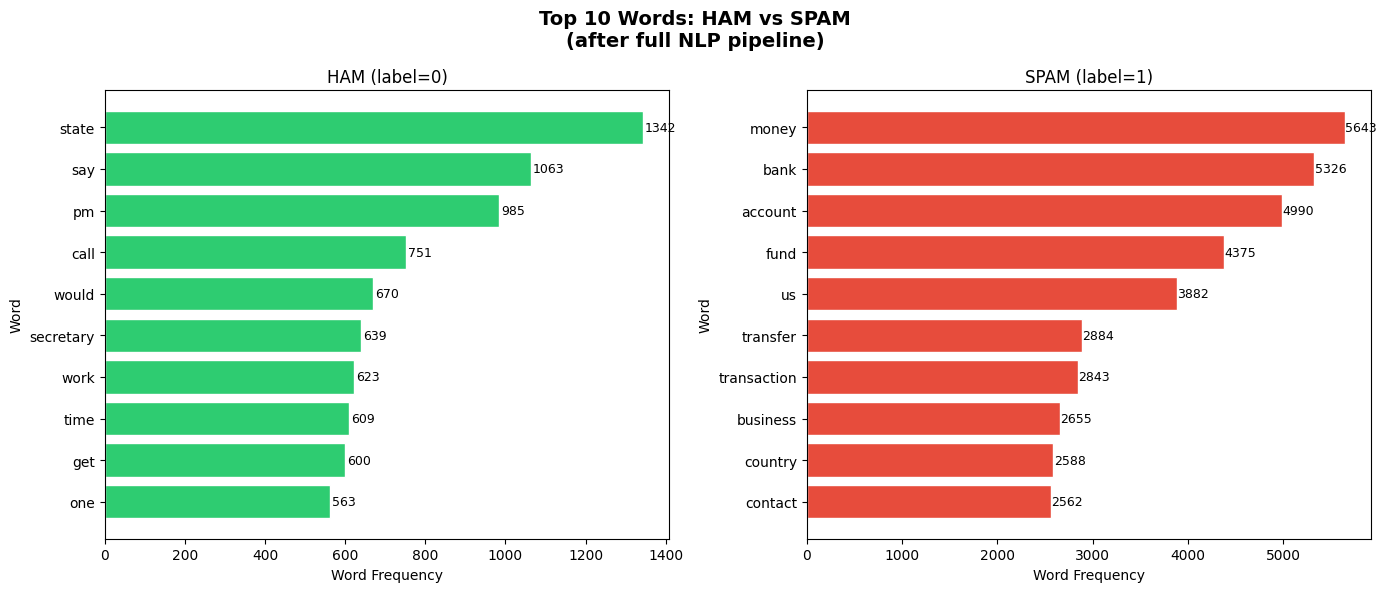

Chart saved.


In [ ]:
# Your code
import pandas as pd
import re
import nltk
import html
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from collections import Counter
import matplotlib.pyplot as plt

# ── Download NLTK resources (run once) ────────────────────────────────────────
nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# ── Rebuild full pipeline (Tasks 3 → 6) ───────────────────────────────────────
def full_pipeline(text):
    if not isinstance(text, str): return ""
    # Task 3: Remove JS, CSS, HTML comments, HTML tags, decode entities
    text = re.sub(r'<script[^>]*>.*?</script>', '', text, flags=re.DOTALL|re.IGNORECASE)
    text = re.sub(r'<style[^>]*>.*?</style>',   '', text, flags=re.DOTALL|re.IGNORECASE)
    text = re.sub(r'<!--.*?-->',  '', text, flags=re.DOTALL)
    text = re.sub(r'<[^>]+>',    '', text)
    text = html.unescape(text)
    # Task 4: Remove byte prefix, special chars, numbers, single chars, normalize
    text = re.sub(r"^b\s*['\"]",       '', text)
    text = re.sub(r'[^a-zA-Z0-9\s]',  ' ', text)
    text = re.sub(r'\d+',              ' ', text)
    text = re.sub(r'\b[a-zA-Z]\b',     '', text)
    text = re.sub(r'\s+[a-zA-Z]\s+',  ' ', text)
    text = re.sub(r'\s+',              ' ', text).strip().lower()
    # Task 5 & 6: Tokenize, remove stopwords, lemmatize
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words]
    lemmas = [lemmatizer.lemmatize(t, pos='v') for t in tokens]
    return ' '.join(lemmas)

# ── Load and preprocess ────────────────────────────────────────────────────────
df_train = pd.read_csv("kg_train.csv", encoding='latin-1')
df_train['preprocessed_text'] = df_train['text'].apply(full_pipeline)

# ══════════════════════════════════════════════════════════════════════════════
# TASK 7.1 — Top 10 words in HAM (label = 0)
# ══════════════════════════════════════════════════════════════════════════════
# Filter only HAM rows → join all text into one large string
# → split into token list → count with Counter → grab top 10
ham_corpus = ' '.join(df_train[df_train['label'] == 0]['preprocessed_text'])
ham_top10  = Counter(ham_corpus.split()).most_common(10)

# ══════════════════════════════════════════════════════════════════════════════
# TASK 7.2 — Top 10 words in SPAM (label = 1)
# ══════════════════════════════════════════════════════════════════════════════
spam_corpus = ' '.join(df_train[df_train['label'] == 1]['preprocessed_text'])
spam_top10  = Counter(spam_corpus.split()).most_common(10)

# ── Print tables ───────────────────────────────────────────────────────────────
print("TOP 10 HAM WORDS")
print(f"{'Rank':<6}{'Word':<20}{'Count'}")
print("-" * 35)
for i, (w, c) in enumerate(ham_top10, 1):
    print(f"{i:<6}{w:<20}{c}")

print("\nTOP 10 SPAM WORDS")
print(f"{'Rank':<6}{'Word':<20}{'Count'}")
print("-" * 35)
for i, (w, c) in enumerate(spam_top10, 1):
    print(f"{i:<6}{w:<20}{c}")

# ── Visualisation: Side-by-side horizontal bar charts ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Top 10 Words: HAM vs SPAM\n(after full NLP pipeline)", fontsize=14, fontweight='bold')

# HAM chart — reverse list so #1 word appears at TOP of the chart
ham_w = [w for w, _ in ham_top10][::-1]
ham_c = [c for _, c in ham_top10][::-1]
axes[0].barh(ham_w, ham_c, color='#2ecc71', edgecolor='white')  # Green = HAM = safe
axes[0].set_title("HAM (label=0)", fontsize=12)
axes[0].set_xlabel("Word Frequency")
axes[0].set_ylabel("Word")
# Annotate count values at end of each bar for easy reading
for i, v in enumerate(ham_c):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=9)

# SPAM chart
spam_w = [w for w, _ in spam_top10][::-1]
spam_c = [c for _, c in spam_top10][::-1]
axes[1].barh(spam_w, spam_c, color='#e74c3c', edgecolor='white')  # Red = SPAM = danger
axes[1].set_title("SPAM (label=1)", fontsize=12)
axes[1].set_xlabel("Word Frequency")
axes[1].set_ylabel("Word")
for i, v in enumerate(spam_c):
    axes[1].text(v + 5, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.savefig("top10_words_ham_spam.png", dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")


## Extra features

In [ ]:
# We add to the original dataframe two additional indicators (money symbols and suspicious words).
""" money_simbol_list = "|".join(["euro","dollar","pound","€",r"\$"])
suspicious_words = "|".join(["free","cheap","sex","money","account","bank","fund","transfer","transaction","win","deposit","password"])

data_train['money_mark'] = data_train['preprocessed_text'].str.contains(money_simbol_list)*1
data_train['suspicious_words'] = data_train['preprocessed_text'].str.contains(suspicious_words)*1
data_train['text_len'] = data_train['preprocessed_text'].apply(lambda x: len(x)) 

data_val['money_mark'] = data_val['preprocessed_text'].str.contains(money_simbol_list)*1
data_val['suspicious_words'] = data_val['preprocessed_text'].str.contains(suspicious_words)*1
data_val['text_len'] = data_val['preprocessed_text'].apply(lambda x: len(x)) 

data_train.head() """
import pandas as pd
import re
import html
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split

nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# ── Rebuild full pipeline (Tasks 3 → 6) ───────────────────────────────────────
def full_pipeline(text):
    if not isinstance(text, str): return ""
    text = re.sub(r'<script[^>]*>.*?</script>', '', text, flags=re.DOTALL|re.IGNORECASE)
    text = re.sub(r'<style[^>]*>.*?</style>',   '', text, flags=re.DOTALL|re.IGNORECASE)
    text = re.sub(r'<!--.*?-->',  '', text, flags=re.DOTALL)
    text = re.sub(r'<[^>]+>',    '', text)
    text = html.unescape(text)
    text = re.sub(r"^b\s*['\"]",      '', text)
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\d+',             ' ', text)
    text = re.sub(r'\b[a-zA-Z]\b',    '', text)
    text = re.sub(r'\s+[a-zA-Z]\s+', ' ', text)
    text = re.sub(r'\s+',             ' ', text).strip().lower()
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words]
    lemmas = [lemmatizer.lemmatize(t, pos='v') for t in tokens]
    return ' '.join(lemmas)

# ── Load data and apply preprocessing ─────────────────────────────────────────
df       = pd.read_csv("kg_train.csv", encoding='latin-1')
df_test  = pd.read_csv("kg_test.csv",  encoding='latin-1')

df['preprocessed_text']      = df['text'].apply(full_pipeline)
df_test['preprocessed_text'] = df_test['text'].apply(full_pipeline)

# ── Train / Validation split (stratified, from Task 2.1) ──────────────────────
# Split BEFORE adding features — features must be derived independently
# on train and val to prevent any form of data leakage
seed = 42
df_train, df_val = train_test_split(
    df,
    test_size=0.25,
    random_state=seed,
    stratify=df['label']  # Preserve 56/44 class ratio in both splits
)

# Reset index after split so .iloc[] and .loc[] behave predictably
df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)

# ══════════════════════════════════════════════════════════════════════════════
# FEATURE 1 — money_mark (binary flag: 0 or 1)
# ══════════════════════════════════════════════════════════════════════════════
# Detects if an email mentions any currency-related terms
# r"\$" — raw string needed because $ is a regex special char (end-of-string anchor)
# "|".join() builds a single OR pattern: "euro|dollar|pound|€|\$"
# .str.contains() returns True/False → multiply by 1 converts to integer 0 or 1
money_symbol_list = "|".join(["euro", "dollar", "pound", "€", r"\$"])

df_train['money_mark'] = df_train['preprocessed_text'].str.contains(
    money_symbol_list,   # Regex pattern to search for
    regex=True           # Explicitly use regex mode (default is True, but explicit is clear)
) * 1                    # True → 1 (spam signal), False → 0

df_val['money_mark']   = df_val['preprocessed_text'].str.contains(
    money_symbol_list, regex=True) * 1

df_test['money_mark']  = df_test['preprocessed_text'].str.contains(
    money_symbol_list, regex=True) * 1

# ══════════════════════════════════════════════════════════════════════════════
# FEATURE 2 — suspicious_words (binary flag: 0 or 1)
# ══════════════════════════════════════════════════════════════════════════════
# Detects if an email contains ANY word from a curated fraud/spam vocabulary
# These words were chosen from domain knowledge — confirmed by Task 7.2 EDA
# where "fund", "transfer", "account", "bank" topped the SPAM word chart
suspicious_words = "|".join([
    "free", "cheap", "sex",       # Classic spam bait words
    "money", "account", "bank",   # Financial fraud indicators
    "fund", "transfer",           # Wire fraud language (most common in this dataset)
    "transaction", "win",         # Lottery/prize scam language
    "deposit", "password"         # Credential theft / banking fraud
])

df_train['suspicious_words'] = df_train['preprocessed_text'].str.contains(
    suspicious_words, regex=True) * 1

df_val['suspicious_words']   = df_val['preprocessed_text'].str.contains(
    suspicious_words, regex=True) * 1

df_test['suspicious_words']  = df_test['preprocessed_text'].str.contains(
    suspicious_words, regex=True) * 1

# ══════════════════════════════════════════════════════════════════════════════
# FEATURE 3 — text_len (numeric: character count of preprocessed text)
# ══════════════════════════════════════════════════════════════════════════════
# SPAM emails tend to be significantly longer than HAM — they need to tell a
# convincing story (inheritance scam, lottery win, etc.)
# HAM emails are typically short and direct
# lambda x: len(x) counts characters in each preprocessed email string
df_train['text_len'] = df_train['preprocessed_text'].apply(lambda x: len(x))
df_val['text_len']   = df_val['preprocessed_text'].apply(lambda x: len(x))
df_test['text_len']  = df_test['preprocessed_text'].apply(lambda x: len(x))

# ── Verification: Feature distribution by class ────────────────────────────────
print("=" * 55)
print("FEATURE STATS — TRAINING SET")
print("=" * 55)

# money_mark: what % of SPAM vs HAM contains currency language?
print("\nmoney_mark by class (% with flag = 1):")
print(df_train.groupby('label')['money_mark'].mean().mul(100).round(1).to_string())

# suspicious_words: what % of SPAM vs HAM contains fraud vocabulary?
print("\nsuspicious_words by class (% with flag = 1):")
print(df_train.groupby('label')['suspicious_words'].mean().mul(100).round(1).to_string())

# text_len: what is the average email length per class?
print("\ntext_len by class (average character count):")
print(df_train.groupby('label')['text_len'].mean().round(0).to_string())

# Quick sanity check: show one row per class to confirm feature values
print("\n── Sample HAM row (label=0) ──────────────────────────────")
ham_sample = df_train[df_train['label'] == 0][
    ['label','money_mark','suspicious_words','text_len','preprocessed_text']
].iloc[0]
print(ham_sample.to_string())

print("\n── Sample SPAM row (label=1) ─────────────────────────────")
spam_sample = df_train[df_train['label'] == 1][
    ['label','money_mark','suspicious_words','text_len','preprocessed_text']
].iloc[0]
print(spam_sample.to_string())

# Final shape confirmation
print(f"\ndf_train shape : {df_train.shape}")
print(f"df_val shape   : {df_val.shape}")
print(f"df_test shape  : {df_test.shape}")
print(f"\nColumns in df_train:\n{list(df_train.columns)}")


<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
C:\Users\KaoticCharma\AppData\Local\Temp\ipykernel_18928\1361626392.py:2: SyntaxWarning: invalid escape sequence '\$'
  """ money_simbol_list = "|".join(["euro","dollar","pound","€",r"\$"])


FEATURE STATS — TRAINING SET

money_mark by class (% with flag = 1):
label
0     2.2
1    64.0

suspicious_words by class (% with flag = 1):
label
0     7.2
1    88.0

text_len by class (average character count):
label
0     341.0
1    1537.0

── Sample HAM row (label=0) ──────────────────────────────
label                                                                0
money_mark                                                           0
suspicious_words                                                     0
text_len                                                           691
preprocessed_text    parliamentary labour party meet gordon survive...

── Sample SPAM row (label=1) ─────────────────────────────
label                                                                1
money_mark                                                           1
suspicious_words                                                     1
text_len                                                          139

## How would work the Bag of Words with Count Vectorizer concept?

In [ ]:
# Your code
import pandas as pd
import re
import html
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def full_pipeline(text):
    if not isinstance(text, str): return ""
    text = re.sub(r'<script[^>]*>.*?</script>', '', text, flags=re.DOTALL|re.IGNORECASE)
    text = re.sub(r'<style[^>]*>.*?</style>',   '', text, flags=re.DOTALL|re.IGNORECASE)
    text = re.sub(r'<!--.*?-->',  '', text, flags=re.DOTALL)
    text = re.sub(r'<[^>]+>',    '', text)
    text = html.unescape(text)
    text = re.sub(r"^b\s*['\"]",      '', text)
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\d+',             ' ', text)
    text = re.sub(r'\b[a-zA-Z]\b',    '', text)
    text = re.sub(r'\s+[a-zA-Z]\s+', ' ', text)
    text = re.sub(r'\s+',             ' ', text).strip().lower()
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words]
    lemmas = [lemmatizer.lemmatize(t, pos='v') for t in tokens]
    return ' '.join(lemmas)

# ── Load, preprocess, split ────────────────────────────────────────────────────
df      = pd.read_csv("kg_train.csv", encoding='latin-1')
df_test = pd.read_csv("kg_test.csv",  encoding='latin-1')
df['preprocessed_text']      = df['text'].apply(full_pipeline)
df_test['preprocessed_text'] = df_test['text'].apply(full_pipeline)

seed = 42
df_train, df_val = train_test_split(df, test_size=0.25, random_state=seed, stratify=df['label'])
df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)

X_train = df_train['preprocessed_text']
X_val   = df_val['preprocessed_text']
y_train = df_train['label']
y_val   = df_val['label']

# ══════════════════════════════════════════════════════════════════════════════
# CONCEPT: How Bag of Words works
# ══════════════════════════════════════════════════════════════════════════════
# BoW treats each document as an UNORDERED collection of words (a "bag")
# It builds a vocabulary of all unique words seen across all documents,
# then represents each document as a vector of word COUNTS
#
# Example with 3 tiny documents:
#   Doc 1: "free money win"
#   Doc 2: "transfer money bank"
#   Doc 3: "let meet tomorrow"
#
# Vocabulary (sorted): [bank, free, meet, money, tomorrow, transfer, win]
#
# Doc 1 vector: [0, 1, 0, 1, 0, 0, 1]  ← count of each vocab word in Doc 1
# Doc 2 vector: [1, 0, 0, 1, 0, 1, 0]
# Doc 3 vector: [0, 0, 1, 0, 1, 0, 0]
#
# This matrix is the "Bag of Words" representation — shape: (n_docs, vocab_size)

# ── Demo: Manual BoW on tiny corpus to make the concept crystal clear ──────────
from sklearn.feature_extraction.text import CountVectorizer

demo_docs = [
    "free money win",       # Fake SPAM
    "transfer money bank",  # Fake SPAM
    "let meet tomorrow"     # Fake HAM
]

demo_vec = CountVectorizer()
demo_matrix = demo_vec.fit_transform(demo_docs)  # Returns a sparse matrix

print("── BoW CONCEPT DEMO ─────────────────────────────────────")
print(f"Vocabulary : {demo_vec.get_feature_names_out()}")
print(f"Matrix shape: {demo_matrix.shape}  (3 docs × {len(demo_vec.vocabulary_)} unique words)")
print("\nBoW matrix (dense view):")
print(demo_matrix.toarray())  # .toarray() converts sparse → dense for display only

# ══════════════════════════════════════════════════════════════════════════════
# REAL IMPLEMENTATION — CountVectorizer on email dataset
# ══════════════════════════════════════════════════════════════════════════════
# max_features=5000  → keep only the 5000 most frequent words in vocabulary
#                     prevents memory explosion on large datasets
# ngram_range=(1,2)  → include both single words (unigrams) AND
#                     two-word combinations (bigrams) e.g. "bank transfer"
#                     Bigrams capture context that single words miss
# min_df=2           → ignore words that appear in fewer than 2 documents
#                     removes ultra-rare words/typos that add noise, not signal
# max_df=0.95        → ignore words appearing in >95% of documents
#                     removes near-universal words that carry no discriminative power
bow_vectorizer = CountVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

# ── CRITICAL: fit ONLY on training data, transform both train and val ──────────
# Fitting on validation data = data leakage — the model would "know" val vocab
# during training, giving falsely optimistic results
X_train_bow = bow_vectorizer.fit_transform(X_train)  # Learn vocab + transform
X_val_bow   = bow_vectorizer.transform(X_val)        # Transform ONLY (no fit)
X_test_bow  = bow_vectorizer.transform(df_test['preprocessed_text'])  # Same

# ── Shape and vocabulary diagnostics ──────────────────────────────────────────
print("\n── REAL BOW RESULTS ─────────────────────────────────────")
print(f"X_train_bow shape : {X_train_bow.shape}")
# Rows = number of training emails, Cols = vocabulary size (up to 5000)

print(f"X_val_bow shape   : {X_val_bow.shape}")
print(f"X_test_bow shape  : {X_test_bow.shape}")

# Sparsity check: what % of the matrix cells are ZERO?
# BoW matrices are almost always >99% sparse — most words don't appear in most docs
total_cells    = X_train_bow.shape[0] * X_train_bow.shape[1]
non_zero_cells = X_train_bow.nnz   # .nnz = number of non-zero entries
sparsity       = (1 - non_zero_cells / total_cells) * 100
print(f"\nMatrix sparsity   : {sparsity:.2f}%")
print(f"Non-zero entries  : {non_zero_cells:,} out of {total_cells:,} total cells")

# Show the 20 most frequent features (tokens) in the training vocabulary
feature_names    = bow_vectorizer.get_feature_names_out()
word_frequencies = X_train_bow.sum(axis=0).A1  # Sum each column = total count per word
top20_idx        = word_frequencies.argsort()[::-1][:20]  # Indices of top 20 by frequency

print("\nTop 20 most frequent BoW features (train set):")
print(f"{'Rank':<6}{'Feature':<25}{'Total Count'}")
print("-" * 40)
for rank, idx in enumerate(top20_idx, 1):
    print(f"{rank:<6}{feature_names[idx]:<25}{int(word_frequencies[idx])}")


── BoW CONCEPT DEMO ─────────────────────────────────────
Vocabulary : ['bank' 'free' 'let' 'meet' 'money' 'tomorrow' 'transfer' 'win']
Matrix shape: (3, 8)  (3 docs × 8 unique words)

BoW matrix (dense view):
[[0 1 0 0 1 0 0 1]
 [1 0 0 0 1 0 1 0]
 [0 0 1 1 0 1 0 0]]

── REAL BOW RESULTS ─────────────────────────────────────
X_train_bow shape : (4473, 5000)
X_val_bow shape   : (1491, 5000)
X_test_bow shape  : (5964, 5000)

Matrix sparsity   : 98.45%
Non-zero entries  : 347,107 out of 22,365,000 total cells

Top 20 most frequent BoW features (train set):
Rank  Feature                  Total Count
----------------------------------------
1     money                    4292
2     bank                     4047
3     account                  3782
4     fund                     3405
5     us                       3266
6     transfer                 2154
7     business                 2112
8     transaction              2097
9     country                  2089
10    contact                  1

## TF-IDF

- Load the vectorizer

- Vectorize all dataset

- print the shape of the vetorized dataset

In [ ]:
# Your code
import pandas as pd
import re
import html
import nltk
import numpy as np
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def full_pipeline(text):
    if not isinstance(text, str): return ""
    text = re.sub(r'<script[^>]*>.*?</script>', '', text, flags=re.DOTALL|re.IGNORECASE)
    text = re.sub(r'<style[^>]*>.*?</style>',   '', text, flags=re.DOTALL|re.IGNORECASE)
    text = re.sub(r'<!--.*?-->',  '', text, flags=re.DOTALL)
    text = re.sub(r'<[^>]+>',    '', text)
    text = html.unescape(text)
    text = re.sub(r"^b\s*['\"]",      '', text)
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\d+',             ' ', text)
    text = re.sub(r'\b[a-zA-Z]\b',    '', text)
    text = re.sub(r'\s+[a-zA-Z]\s+', ' ', text)
    text = re.sub(r'\s+',             ' ', text).strip().lower()
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words]
    lemmas = [lemmatizer.lemmatize(t, pos='v') for t in tokens]
    return ' '.join(lemmas)

# ── Load, preprocess, split ────────────────────────────────────────────────────
df      = pd.read_csv("kg_train.csv", encoding='latin-1')
df_test = pd.read_csv("kg_test.csv",  encoding='latin-1')
df['preprocessed_text']      = df['text'].apply(full_pipeline)
df_test['preprocessed_text'] = df_test['text'].apply(full_pipeline)

seed = 42
df_train, df_val = train_test_split(df, test_size=0.25, random_state=seed, stratify=df['label'])
df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)

X_train = df_train['preprocessed_text']
X_val   = df_val['preprocessed_text']
y_train = df_train['label']
y_val   = df_val['label']

# ══════════════════════════════════════════════════════════════════════════════
# CONCEPT: How TF-IDF works
# ══════════════════════════════════════════════════════════════════════════════
# TF-IDF = Term Frequency × Inverse Document Frequency
#
# TF (Term Frequency):
#   How often a word appears in ONE specific document
#   TF(word, doc) = count(word in doc) / total words in doc
#   e.g. "transfer" appears 5 times in a 100-word email → TF = 0.05
#
# IDF (Inverse Document Frequency):
#   How RARE a word is across ALL documents
#   IDF(word) = log( total_docs / docs_containing_word )
#   e.g. "transfer" in 50 of 5000 docs → IDF = log(5000/50) = log(100) ≈ 4.6
#   e.g. "the"      in 4999 of 5000 docs → IDF = log(5000/4999) ≈ 0.0002
#
# TF-IDF(word, doc) = TF × IDF
#   → High score: word appears OFTEN in THIS doc but RARELY across all docs
#   → Low score : word appears everywhere (stopwords) OR rarely in this doc
#
# Why this beats raw BoW for spam detection:
#   "transfer" is rare globally but frequent in SPAM → HIGH TF-IDF in spam docs
#   "know"     is common globally and in HAM → LOW TF-IDF everywhere

# ── TASK 10.1 — Load (initialise) the TF-IDF Vectorizer ───────────────────────
# sublinear_tf=True  → replaces raw TF with 1 + log(TF)
#                      dampens the effect of very high word counts
#                      prevents "transfer × 50" from dominating over "transfer × 5"
# max_features=5000  → cap vocabulary at 5000 most informative terms
# ngram_range=(1,2)  → unigrams + bigrams (same rationale as BoW in Task 9)
# min_df=2           → drop words appearing in fewer than 2 documents
# max_df=0.95        → drop words appearing in >95% of documents (near-universal)
# norm='l2'          → L2-normalise each document vector so all docs have
#                      unit length — prevents long SPAM emails from dominating
#                      purely because they have more words
tfidf_vectorizer = TfidfVectorizer(
    sublinear_tf=True,
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    norm='l2'
)

# ── TASK 10.2 — Vectorize the full dataset ────────────────────────────────────
# RULE: fit_transform on TRAIN only → transform on VAL and TEST
# fit_transform: learns the vocabulary and IDF weights from training data,
#                then converts training text into TF-IDF matrix
# transform:     uses the ALREADY LEARNED vocabulary/IDF to convert new text
#                never re-learns on val/test — that would be data leakage
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)  # Learn + transform
X_val_tfidf   = tfidf_vectorizer.transform(X_val)        # Transform only
X_test_tfidf  = tfidf_vectorizer.transform(df_test['preprocessed_text'])

# ── TASK 10.3 — Print shape of vectorized datasets ────────────────────────────
print("=" * 55)
print("TF-IDF VECTORIZED DATASET SHAPES")
print("=" * 55)
print(f"X_train_tfidf : {X_train_tfidf.shape}")
# (rows=training emails, cols=vocabulary size up to 5000)
print(f"X_val_tfidf   : {X_val_tfidf.shape}")
print(f"X_test_tfidf  : {X_test_tfidf.shape}")

# ── Sparsity check ─────────────────────────────────────────────────────────────
total     = X_train_tfidf.shape[0] * X_train_tfidf.shape[1]
non_zero  = X_train_tfidf.nnz
sparsity  = (1 - non_zero / total) * 100
print(f"\nSparsity      : {sparsity:.2f}%")
print(f"Non-zero cells: {non_zero:,} of {total:,}")

# ── Vocabulary diagnostics ─────────────────────────────────────────────────────
vocab_size = len(tfidf_vectorizer.vocabulary_)
print(f"\nVocabulary size (unique tokens): {vocab_size:,}")

# ── Top 15 highest average TF-IDF scoring words in SPAM emails ────────────────
# This shows which words the vectorizer has given the highest discriminative weight
# for spam — these will be the strongest features for the classifier in Task 11

feature_names = tfidf_vectorizer.get_feature_names_out()

# Get TF-IDF matrix rows that belong to SPAM emails (label=1)
spam_mask         = y_train.values == 1
X_train_tfidf_arr = X_train_tfidf.toarray()  # Dense only for this diagnostic

spam_tfidf_means = X_train_tfidf_arr[spam_mask].mean(axis=0)  # Mean score per feature
ham_tfidf_means  = X_train_tfidf_arr[~spam_mask].mean(axis=0)

# Top 15 features by SPAM mean TF-IDF score
top15_spam_idx = spam_tfidf_means.argsort()[::-1][:15]

print("\nTop 15 highest mean TF-IDF features in SPAM emails:")
print(f"{'Rank':<6}{'Feature':<25}{'SPAM mean':>12}{'HAM mean':>12}")
print("-" * 55)
for rank, idx in enumerate(top15_spam_idx, 1):
    print(f"{rank:<6}{feature_names[idx]:<25}"
          f"{spam_tfidf_means[idx]:>12.5f}"
          f"{ham_tfidf_means[idx]:>12.5f}")

# ── Demonstrate TF-IDF score on a single document ─────────────────────────────
# Shows what a TF-IDF row vector looks like for one specific email
sample_vec  = X_train_tfidf[0].toarray()[0]     # First training email as dense array
nonzero_idx = sample_vec.nonzero()[0]            # Indices of non-zero features only

print(f"\nTF-IDF vector for training email #0 (showing non-zero features only):")
print(f"{'Token':<25}{'TF-IDF Score':>15}")
print("-" * 40)
# Sort by score descending for easy reading
sorted_idx = nonzero_idx[sample_vec[nonzero_idx].argsort()[::-1]]
for idx in sorted_idx[:10]:                      # Show top 10 scoring tokens only
    print(f"{feature_names[idx]:<25}{sample_vec[idx]:>15.5f}")


TF-IDF VECTORIZED DATASET SHAPES
X_train_tfidf : (4473, 5000)
X_val_tfidf   : (1491, 5000)
X_test_tfidf  : (5964, 5000)

Sparsity      : 98.45%
Non-zero cells: 347,107 of 22,365,000

Vocabulary size (unique tokens): 5,000

Top 15 highest mean TF-IDF features in SPAM emails:
Rank  Feature                     SPAM mean    HAM mean
-------------------------------------------------------
1     money                         0.04166     0.00039
2     bank                          0.03969     0.00027
3     fund                          0.03942     0.00049
4     account                       0.03790     0.00031
5     us                            0.03455     0.00516
6     contact                       0.02985     0.00133
7     transaction                   0.02985     0.00000
8     transfer                      0.02964     0.00024
9     business                      0.02880     0.00069
10    country                       0.02821     0.00120
11    mr                            0.02809     0.001

## And then Train a Classifier?

LOGISTIC REGRESSION — TF-IDF CLASSIFIER RESULTS

Accuracy  : 98.32%
ROC-AUC   : 0.9978

Classification Report:

              precision    recall  f1-score   support

     HAM (0)       0.97      1.00      0.99       847
    SPAM (1)       1.00      0.96      0.98       644

    accuracy                           0.98      1491
   macro avg       0.99      0.98      0.98      1491
weighted avg       0.98      0.98      0.98      1491

Confusion Matrix:
              Predicted HAM   Predicted SPAM
Actual HAM         846               1
Actual SPAM         24             620


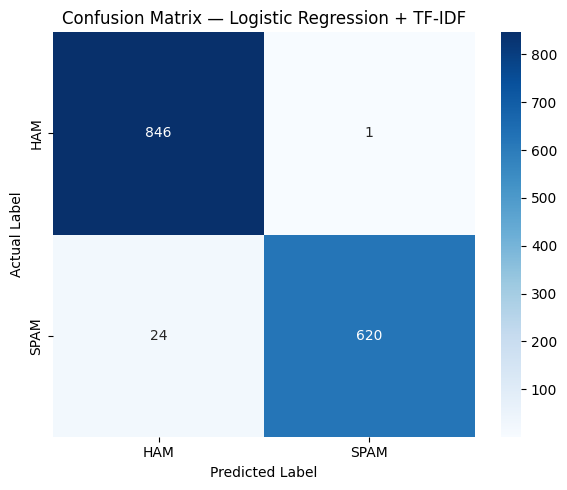


Top 15 most SPAM-predictive features (positive coefficients):
Rank  Feature                      Coefficient
----------------------------------------------
1     bank                              3.6512
2     com                               3.2860
3     mr                                3.2738
4     fund                              3.2530
5     money                             3.2233
6     yahoo                             3.0646
7     account                           2.7976
8     regard                            2.6214
9     contact                           2.5799
10    transaction                       2.5158
11    please                            2.4067
12    px                                2.3414
13    http                              2.3138
14    company                           2.2442
15    mail                              2.2203

Top 15 most HAM-predictive features (negative coefficients):
Rank  Feature                      Coefficient
-----------------------------

In [1]:
# Your code
import pandas as pd
import re
import html
import nltk
import numpy as np
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, roc_auc_score)
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def full_pipeline(text):
    if not isinstance(text, str): return ""
    text = re.sub(r'<script[^>]*>.*?</script>', '', text, flags=re.DOTALL|re.IGNORECASE)
    text = re.sub(r'<style[^>]*>.*?</style>',   '', text, flags=re.DOTALL|re.IGNORECASE)
    text = re.sub(r'<!--.*?-->',  '', text, flags=re.DOTALL)
    text = re.sub(r'<[^>]+>',    '', text)
    text = html.unescape(text)
    text = re.sub(r"^b\s*['\"]",      '', text)
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\d+',             ' ', text)
    text = re.sub(r'\b[a-zA-Z]\b',    '', text)
    text = re.sub(r'\s+[a-zA-Z]\s+', ' ', text)
    text = re.sub(r'\s+',             ' ', text).strip().lower()
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words]
    lemmas = [lemmatizer.lemmatize(t, pos='v') for t in tokens]
    return ' '.join(lemmas)

# ── Load, preprocess, split ────────────────────────────────────────────────────
df      = pd.read_csv("kg_train.csv", encoding='latin-1')
df_test = pd.read_csv("kg_test.csv",  encoding='latin-1')
df['preprocessed_text']      = df['text'].apply(full_pipeline)
df_test['preprocessed_text'] = df_test['text'].apply(full_pipeline)

seed = 42
df_train, df_val = train_test_split(
    df, test_size=0.25, random_state=seed, stratify=df['label']
)
df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)

X_train = df_train['preprocessed_text']
X_val   = df_val['preprocessed_text']
y_train = df_train['label']
y_val   = df_val['label']

# ── TF-IDF Vectorizer (Task 10 settings) ──────────────────────────────────────
tfidf_vectorizer = TfidfVectorizer(
    sublinear_tf=True,   # log(TF)+1 dampens high-frequency dominance
    max_features=5000,   # Top 5000 most informative tokens
    ngram_range=(1, 2),  # Unigrams + bigrams
    min_df=2,            # Ignore tokens in fewer than 2 docs
    max_df=0.95,         # Ignore tokens in more than 95% of docs
    norm='l2'            # L2 normalise — levels short vs long emails
)

# fit on train only — transform val and test separately to avoid leakage
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf   = tfidf_vectorizer.transform(X_val)
X_test_tfidf  = tfidf_vectorizer.transform(df_test['preprocessed_text'])

# ══════════════════════════════════════════════════════════════════════════════
# TASK 11.1 — Train Logistic Regression classifier on TF-IDF features
# ══════════════════════════════════════════════════════════════════════════════
# Why Logistic Regression for text classification?
# → Works well with high-dimensional sparse data (TF-IDF matrices are huge + sparse)
# → Produces probabilities (not just hard labels) — useful for threshold tuning
# → Fast to train even on 5000-feature matrices
# → Coefficients are interpretable — you can see which words drive predictions
#
# solver='lbfgs'   → efficient optimiser for multi-class/large feature sets
# C=1.0            → regularisation strength inverse — higher C = less penalty
#                    = allows the model to fit more closely to training data
#                    lower C = stronger regularisation = more generalisation
# max_iter=1000    → more iterations ensures convergence on high-dim TF-IDF space
#                    default 100 often causes a ConvergenceWarning here
# class_weight='balanced' → adjusts weights inversely to class frequency
#                    compensates for the 56/44 HAM/SPAM imbalance automatically
clf = LogisticRegression(
    solver='lbfgs',
    C=1.0,
    max_iter=1000,
    class_weight='balanced',
    random_state=seed
)

# ── Fit the classifier on TF-IDF training matrix ──────────────────────────────
# X_train_tfidf: sparse matrix (4473 emails × 5000 features)
# y_train:       binary labels (0=HAM, 1=SPAM)
clf.fit(X_train_tfidf, y_train)

# ── Predict on validation set ──────────────────────────────────────────────────
# predict()       → hard class labels (0 or 1)
# predict_proba() → probability scores for each class [P(HAM), P(SPAM)]
y_pred      = clf.predict(X_val_tfidf)
y_pred_prob = clf.predict_proba(X_val_tfidf)[:, 1]  # Probability of SPAM (class=1)

# ── Evaluation Metrics ─────────────────────────────────────────────────────────
print("=" * 55)
print("LOGISTIC REGRESSION — TF-IDF CLASSIFIER RESULTS")
print("=" * 55)

# Accuracy: overall % of correct predictions
print(f"\nAccuracy  : {accuracy_score(y_val, y_pred) * 100:.2f}%")

# ROC-AUC: measures ability to rank SPAM above HAM across all thresholds
# 1.0 = perfect, 0.5 = random guessing
print(f"ROC-AUC   : {roc_auc_score(y_val, y_pred_prob):.4f}")

# Classification report: precision, recall, f1 per class
# Precision: of all predicted SPAM, how many were actually SPAM?
# Recall:    of all actual SPAM, how many did we correctly catch?
# F1-score:  harmonic mean of precision and recall — best single metric
print(f"\nClassification Report:\n")
print(classification_report(y_val, y_pred, target_names=['HAM (0)', 'SPAM (1)']))

# ── Confusion Matrix ───────────────────────────────────────────────────────────
# Rows = actual class, Cols = predicted class
# [TN  FP]   TN = correctly predicted HAM
# [FN  TP]   TP = correctly predicted SPAM
#            FP = HAM predicted as SPAM (false alarm)
#            FN = SPAM predicted as HAM (missed spam — the dangerous error)
cm = confusion_matrix(y_val, y_pred)
print("Confusion Matrix:")
print(f"              Predicted HAM   Predicted SPAM")
print(f"Actual HAM       {cm[0,0]:>5}           {cm[0,1]:>5}")
print(f"Actual SPAM      {cm[1,0]:>5}           {cm[1,1]:>5}")

# ── Visualise confusion matrix ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,          # Show numbers inside cells
    fmt='d',             # Integer format
    cmap='Blues',        # Blue gradient — darker = more predictions in that cell
    xticklabels=['HAM', 'SPAM'],
    yticklabels=['HAM', 'SPAM'],
    ax=ax
)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('Actual Label')
ax.set_title('Confusion Matrix — Logistic Regression + TF-IDF')
plt.tight_layout()
plt.savefig("confusion_matrix_lr_tfidf.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Top 15 most predictive features for SPAM ──────────────────────────────────
# Logistic Regression coefficients directly measure feature importance
# Positive coefficient = pushes prediction towards SPAM (class=1)
# Negative coefficient = pushes prediction towards HAM  (class=0)
feature_names = tfidf_vectorizer.get_feature_names_out()
coefficients  = clf.coef_[0]               # One coefficient per feature

# Indices of 15 largest positive coefficients → most SPAM-predictive features
top15_spam_idx = coefficients.argsort()[::-1][:15]

# Indices of 15 largest negative coefficients → most HAM-predictive features
top15_ham_idx  = coefficients.argsort()[:15]

print("\nTop 15 most SPAM-predictive features (positive coefficients):")
print(f"{'Rank':<6}{'Feature':<28}{'Coefficient':>12}")
print("-" * 46)
for rank, idx in enumerate(top15_spam_idx, 1):
    print(f"{rank:<6}{feature_names[idx]:<28}{coefficients[idx]:>12.4f}")

print("\nTop 15 most HAM-predictive features (negative coefficients):")
print(f"{'Rank':<6}{'Feature':<28}{'Coefficient':>12}")
print("-" * 46)
for rank, idx in enumerate(top15_ham_idx, 1):
    print(f"{rank:<6}{feature_names[idx]:<28}{coefficients[idx]:>12.4f}")

# ── Generate final predictions on Kaggle test set ─────────────────────────────
# This is what you would submit to Kaggle
final_predictions = clf.predict(X_test_tfidf)
submission = pd.DataFrame({
    'id':    range(len(final_predictions)),   # Row index as ID
    'label': final_predictions                # 0=HAM, 1=SPAM
})
submission.to_csv("submission_lr_tfidf.csv", index=False)
print(f"\nKaggle submission saved → submission_lr_tfidf.csv")
print(f"Predicted SPAM: {final_predictions.sum():,} | Predicted HAM: {(final_predictions==0).sum():,}")


### Extra Task - Implement a SPAM/HAM classifier

https://www.kaggle.com/t/b384e34013d54d238490103bc3c360ce

The classifier can not be changed!!! It must be the MultinimialNB with default parameters!

Your task is to **find the most relevant features**.

For example, you can test the following options and check which of them performs better:
- Using "Bag of Words" only
- Using "TF-IDF" only
- Bag of Words + extra flags (money_mark, suspicious_words, text_len)
- TF-IDF + extra flags


You can work with teams of two persons (recommended).

MultinomialNB — ALL 4 FEATURE COMBINATIONS

─────────────────────────────────────────────────────────────────
  12.1 — BoW Only
─────────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

         HAM       0.98      0.98      0.98       847
        SPAM       0.98      0.98      0.98       644

    accuracy                           0.98      1491
   macro avg       0.98      0.98      0.98      1491
weighted avg       0.98      0.98      0.98      1491

  Kaggle submission saved → submission_bow_only.csv

─────────────────────────────────────────────────────────────────
  12.2 — TF-IDF Only
─────────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

         HAM       0.98      0.99      0.99       847
        SPAM       0.99      0.98      0.98       644

    accuracy                           0.98      1491
   macro avg       0.98      0.98      0.98      1491
w

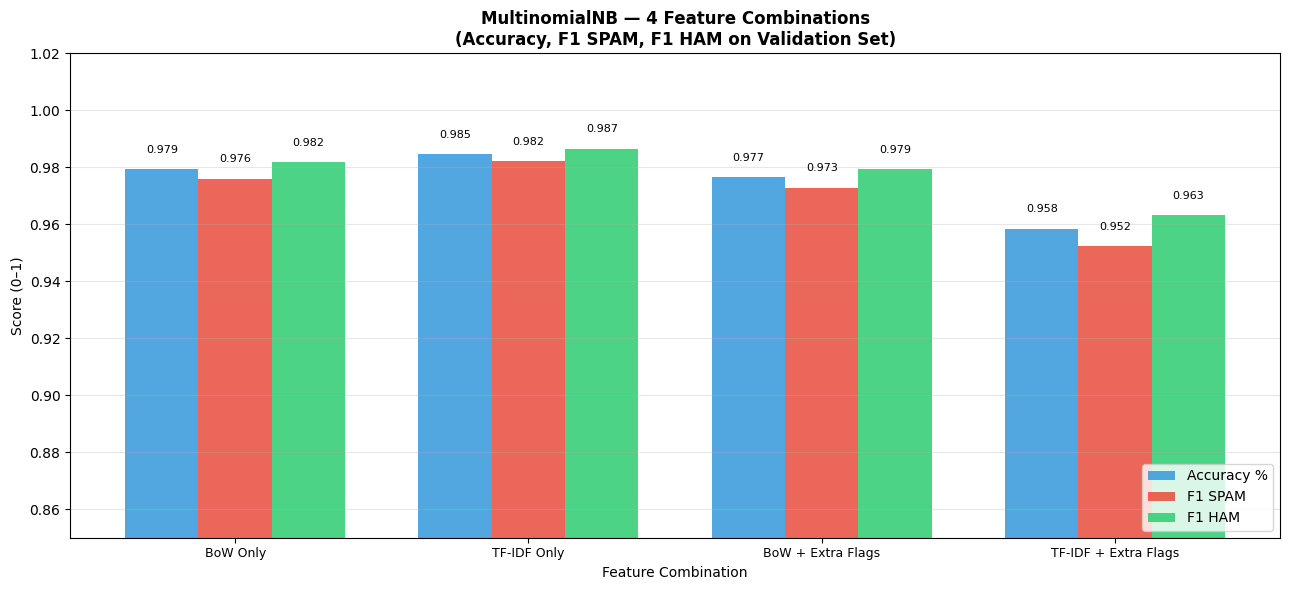

Comparison chart saved → mnb_comparison.png


In [2]:
# Your code
import pandas as pd
import re
import html
import nltk
import numpy as np
import scipy.sparse as sp
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, accuracy_score,
                              roc_auc_score, f1_score)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def full_pipeline(text):
    if not isinstance(text, str): return ""
    text = re.sub(r'<script[^>]*>.*?</script>', '', text, flags=re.DOTALL|re.IGNORECASE)
    text = re.sub(r'<style[^>]*>.*?</style>',   '', text, flags=re.DOTALL|re.IGNORECASE)
    text = re.sub(r'<!--.*?-->',  '', text, flags=re.DOTALL)
    text = re.sub(r'<[^>]+>',    '', text)
    text = html.unescape(text)
    text = re.sub(r"^b\s*['\"]",      '', text)
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\d+',             ' ', text)
    text = re.sub(r'\b[a-zA-Z]\b',    '', text)
    text = re.sub(r'\s+[a-zA-Z]\s+', ' ', text)
    text = re.sub(r'\s+',             ' ', text).strip().lower()
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words]
    lemmas = [lemmatizer.lemmatize(t, pos='v') for t in tokens]
    return ' '.join(lemmas)

# ── Load, preprocess, split ────────────────────────────────────────────────────
df      = pd.read_csv("kg_train.csv", encoding='latin-1')
df_test = pd.read_csv("kg_test.csv",  encoding='latin-1')
df['preprocessed_text']      = df['text'].apply(full_pipeline)
df_test['preprocessed_text'] = df_test['text'].apply(full_pipeline)

seed = 42
df_train, df_val = train_test_split(
    df, test_size=0.25, random_state=seed, stratify=df['label']
)
df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)

X_train_text = df_train['preprocessed_text']
X_val_text   = df_val['preprocessed_text']
X_test_text  = df_test['preprocessed_text']
y_train      = df_train['label']
y_val        = df_val['label']

# ══════════════════════════════════════════════════════════════════════════════
# BUILD EXTRA FLAGS (Task 8) — money_mark, suspicious_words, text_len
# ══════════════════════════════════════════════════════════════════════════════
# These 3 handcrafted features capture domain knowledge the vectorizer misses
money_symbols    = "|".join(["euro", "dollar", "pound", "€", r"\$"])
suspicious_vocab = "|".join([
    "free", "cheap", "sex", "money", "account", "bank",
    "fund", "transfer", "transaction", "win", "deposit", "password"
])

def build_extra_flags(df_split):
    # Returns a dense numpy array of shape (n_samples, 3)
    # Column 0: money_mark      — binary 0/1
    # Column 1: suspicious_words — binary 0/1
    # Column 2: text_len         — integer character count
    # MultinomialNB requires ALL features to be NON-NEGATIVE integers/floats
    # text_len satisfies this naturally; binary flags are 0 or 1
    money   = df_split['preprocessed_text'].str.contains(money_symbols,    regex=True).astype(int)
    susp    = df_split['preprocessed_text'].str.contains(suspicious_vocab, regex=True).astype(int)
    tlen    = df_split['preprocessed_text'].apply(len).astype(int)
    return np.column_stack([money.values, susp.values, tlen.values])

extra_train = build_extra_flags(df_train)   # shape: (4473, 3)
extra_val   = build_extra_flags(df_val)     # shape: (1491, 3)
extra_test  = build_extra_flags(df_test)    # shape: (5964, 3)

# ══════════════════════════════════════════════════════════════════════════════
# BUILD VECTORIZED MATRICES
# ══════════════════════════════════════════════════════════════════════════════
# Bag of Words vectorizer (Task 9 settings)
bow_vec = CountVectorizer(max_features=5000, ngram_range=(1,2), min_df=2, max_df=0.95)
X_train_bow = bow_vec.fit_transform(X_train_text)   # Sparse matrix
X_val_bow   = bow_vec.transform(X_val_text)
X_test_bow  = bow_vec.transform(X_test_text)

# TF-IDF vectorizer (Task 10 settings)
# NOTE: sublinear_tf=True CANNOT be used with MultinomialNB
# MultinomialNB interprets features as counts/frequencies — it requires
# non-negative values. sublinear_tf applies log transform which CAN produce
# values < 0 for TF < 1. We disable it here for strict NB compatibility.
tfidf_vec = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    norm='l2',
    sublinear_tf=False   # Must be False for MultinomialNB — see note above
)
X_train_tfidf = tfidf_vec.fit_transform(X_train_text)
X_val_tfidf   = tfidf_vec.transform(X_val_text)
X_test_tfidf  = tfidf_vec.transform(X_test_text)

# ══════════════════════════════════════════════════════════════════════════════
# COMBINE: vectorized text + extra flags using scipy.sparse.hstack
# ══════════════════════════════════════════════════════════════════════════════
# scipy.sparse.hstack horizontally concatenates sparse + dense matrices
# extra flags must be converted to sparse first via sp.csr_matrix()
# This gives MultinomialNB a richer feature set without breaking sparsity

# BOW + extra flags
X_train_bow_extra = sp.hstack([X_train_bow, sp.csr_matrix(extra_train)])
X_val_bow_extra   = sp.hstack([X_val_bow,   sp.csr_matrix(extra_val)])
X_test_bow_extra  = sp.hstack([X_test_bow,  sp.csr_matrix(extra_test)])

# TF-IDF + extra flags
X_train_tfidf_extra = sp.hstack([X_train_tfidf, sp.csr_matrix(extra_train)])
X_val_tfidf_extra   = sp.hstack([X_val_tfidf,   sp.csr_matrix(extra_val)])
X_test_tfidf_extra  = sp.hstack([X_test_tfidf,  sp.csr_matrix(extra_test)])

# ══════════════════════════════════════════════════════════════════════════════
# TASK 12.1 → 12.4 — Train MultinomialNB on all 4 feature combinations
# ══════════════════════════════════════════════════════════════════════════════
# MultinomialNB: Naive Bayes for multinomially distributed data (word counts)
# "Naive" = assumes all features are CONDITIONALLY INDEPENDENT given the class
# This is obviously wrong (words co-occur) but works surprisingly well in practice
# Default parameters: alpha=1.0 (Laplace smoothing — prevents zero probabilities
# for words seen in validation but not in training)

# Each experiment is a dict: name, X_train, X_val, X_test
experiments = [
    {
        "name"    : "12.1 — BoW Only",
        "X_train" : X_train_bow,
        "X_val"   : X_val_bow,
        "X_test"  : X_test_bow
    },
    {
        "name"    : "12.2 — TF-IDF Only",
        "X_train" : X_train_tfidf,
        "X_val"   : X_val_tfidf,
        "X_test"  : X_test_tfidf
    },
    {
        "name"    : "12.3 — BoW + Extra Flags",
        "X_train" : X_train_bow_extra,
        "X_val"   : X_val_bow_extra,
        "X_test"  : X_test_bow_extra
    },
    {
        "name"    : "12.4 — TF-IDF + Extra Flags",
        "X_train" : X_train_tfidf_extra,
        "X_val"   : X_val_tfidf_extra,
        "X_test"  : X_test_tfidf_extra
    }
]

results = []   # Store results for comparison table and chart

print("=" * 65)
print("MultinomialNB — ALL 4 FEATURE COMBINATIONS")
print("=" * 65)

for exp in experiments:
    # Instantiate a FRESH MultinomialNB for each experiment
    # Default parameters: alpha=1.0 (Laplace smoothing)
    mnb = MultinomialNB()

    # Fit on training features and labels
    mnb.fit(exp["X_train"], y_train)

    # Predict hard labels and SPAM probability scores on validation set
    y_pred      = mnb.predict(exp["X_val"])
    y_pred_prob = mnb.predict_proba(exp["X_val"])[:, 1]  # P(SPAM)

    # Compute metrics
    acc     = accuracy_score(y_val, y_pred) * 100
    roc_auc = roc_auc_score(y_val, y_pred_prob)
    f1_spam = f1_score(y_val, y_pred, pos_label=1)   # F1 for SPAM class
    f1_ham  = f1_score(y_val, y_pred, pos_label=0)   # F1 for HAM class

    results.append({
        "Combination" : exp["name"],
        "Accuracy %"  : round(acc, 2),
        "ROC-AUC"     : round(roc_auc, 4),
        "F1 SPAM"     : round(f1_spam, 4),
        "F1 HAM"      : round(f1_ham, 4)
    })

    print(f"\n{'─'*65}")
    print(f"  {exp['name']}")
    print(f"{'─'*65}")
    print(classification_report(y_val, y_pred, target_names=['HAM', 'SPAM']))

    # Generate and save Kaggle submission for each combination
    final_preds = mnb.predict(exp["X_test"])
    fname       = exp["name"].split("—")[1].strip().lower().replace(" ", "_").replace("+", "plus")
    sub_df      = pd.DataFrame({'id': range(len(final_preds)), 'label': final_preds})
    sub_df.to_csv(f"submission_{fname}.csv", index=False)
    print(f"  Kaggle submission saved → submission_{fname}.csv")

# ══════════════════════════════════════════════════════════════════════════════
# COMPARISON TABLE
# ══════════════════════════════════════════════════════════════════════════════
results_df = pd.DataFrame(results)
print("\n")
print("=" * 65)
print("FINAL COMPARISON — All 4 Combinations")
print("=" * 65)
print(results_df.to_string(index=False))

# Highlight the winner
best_idx  = results_df['F1 SPAM'].idxmax()
best_name = results_df.loc[best_idx, 'Combination']
best_f1   = results_df.loc[best_idx, 'F1 SPAM']
print(f"\n🏆 Best combination by F1 SPAM: {best_name} → F1={best_f1:.4f}")

# ══════════════════════════════════════════════════════════════════════════════
# VISUALISATION — Bar chart comparing all 4 combinations across 3 metrics
# ══════════════════════════════════════════════════════════════════════════════
metrics   = ['Accuracy %', 'F1 SPAM', 'F1 HAM']
labels    = [r['Combination'].split('—')[1].strip() for r in results]
x         = np.arange(len(labels))   # x-positions for groups
width     = 0.25                     # Width of each individual bar
colors    = ['#3498db', '#e74c3c', '#2ecc71']  # Blue, Red, Green per metric

fig, ax = plt.subplots(figsize=(13, 6))

for i, metric in enumerate(metrics):
    vals = [r[metric] if metric != 'Accuracy %'
            else r[metric] / 100        # Normalise accuracy to 0-1 scale
            for r in results]
    bars = ax.bar(x + i * width, vals, width, label=metric, color=colors[i], alpha=0.85)
    # Annotate each bar with its value
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f"{v:.3f}", ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylim(0.85, 1.02)             # Zoom y-axis to show differences clearly
ax.set_ylabel("Score (0–1)")
ax.set_xlabel("Feature Combination")
ax.set_title("MultinomialNB — 4 Feature Combinations\n(Accuracy, F1 SPAM, F1 HAM on Validation Set)",
             fontsize=12, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("mnb_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Comparison chart saved → mnb_comparison.png")
